<a href="https://colab.research.google.com/github/harshpav/CELEBAL-EXCELLENCE-INTERNSHIP-_ASSIGNMENT/blob/main/week2_harsh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# New Section

In [ ]:
# Tesla EV Deliveries Analysis and Forecasting

# This project implements an end-to-end machine learning workflow on Tesla EV delivery data from 2015–2025. The analysis includes data preprocessing, exploratory data analysis, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

# Load Tesla dataset
data_path = "/content/tesla_deliveries_dataset_2015_2025.csv"
tesla_df = pd.read_csv(data_path)

print(f"Dataset Shape: {tesla_df.shape}")
tesla_df.head()

Dataset Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [ ]:
print("Missing Values:")
print(tesla_df.isnull().sum())

print("\nDuplicate Records:")
print(tesla_df.duplicated().sum())

print("\nDataset Information:")
tesla_df.info()

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Records:
0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64 

In [ ]:
# Create a proper datetime column
tesla_df["Date"] = pd.to_datetime(
    tesla_df["Year"].astype(str) + "-" +
    tesla_df["Month"].astype(str)
)

# Business-oriented feature
tesla_df["Delivery_Efficiency"] = (
    tesla_df["Estimated_Deliveries"] /
    tesla_df["Production_Units"]
)

tesla_df[["Date", "Delivery_Efficiency"]].head()

,Date,Delivery_Efficiency
0,2023-05-01,0.984600
1,2015-02-01,0.911864
2,2019-01-01,0.915334
3,2021-02-01,0.896594
4,2016-12-01,0.914087


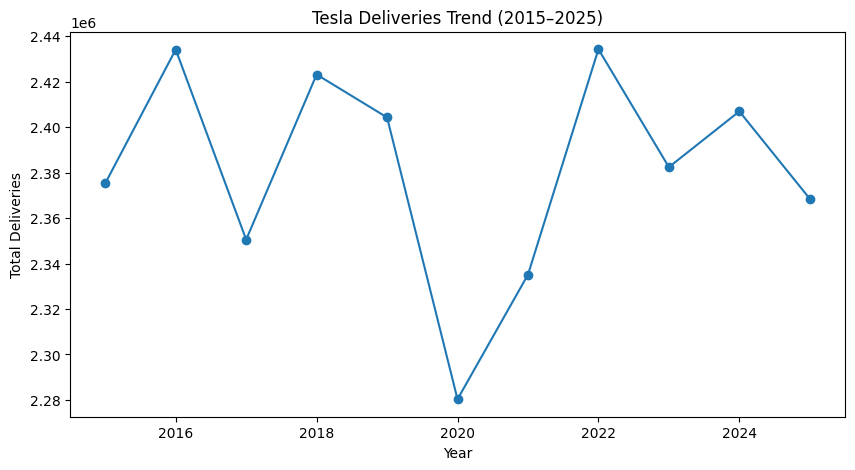

In [ ]:
annual_deliveries = (
    tesla_df.groupby("Year")["Estimated_Deliveries"]
    .sum()
)

plt.figure(figsize=(10,5))
plt.plot(
    annual_deliveries.index,
    annual_deliveries.values,
    marker="o"
)

plt.title("Tesla Deliveries Trend (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Total Deliveries")
plt.show()

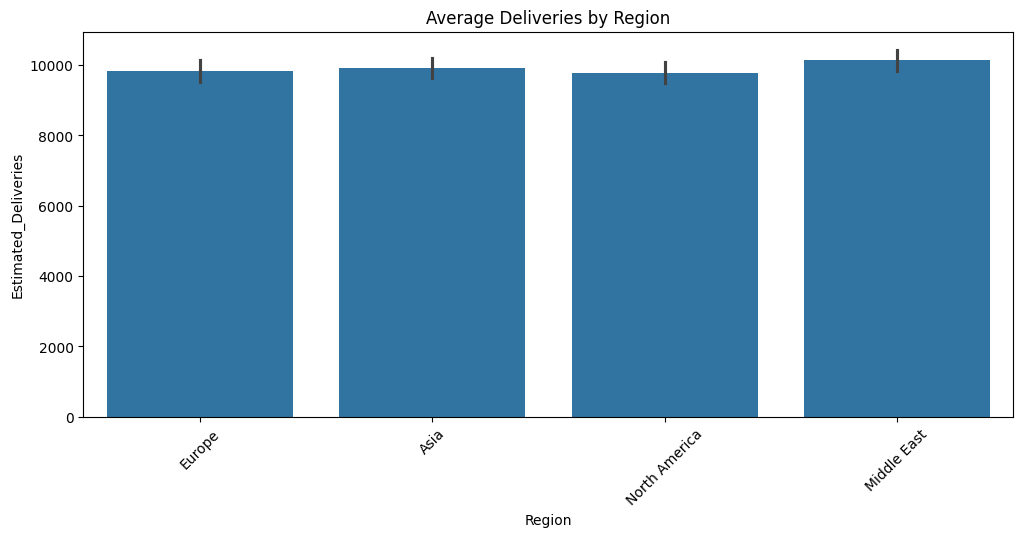

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=tesla_df,
    x="Region",
    y="Estimated_Deliveries"
)

plt.xticks(rotation=45)
plt.title("Average Deliveries by Region")
plt.show()

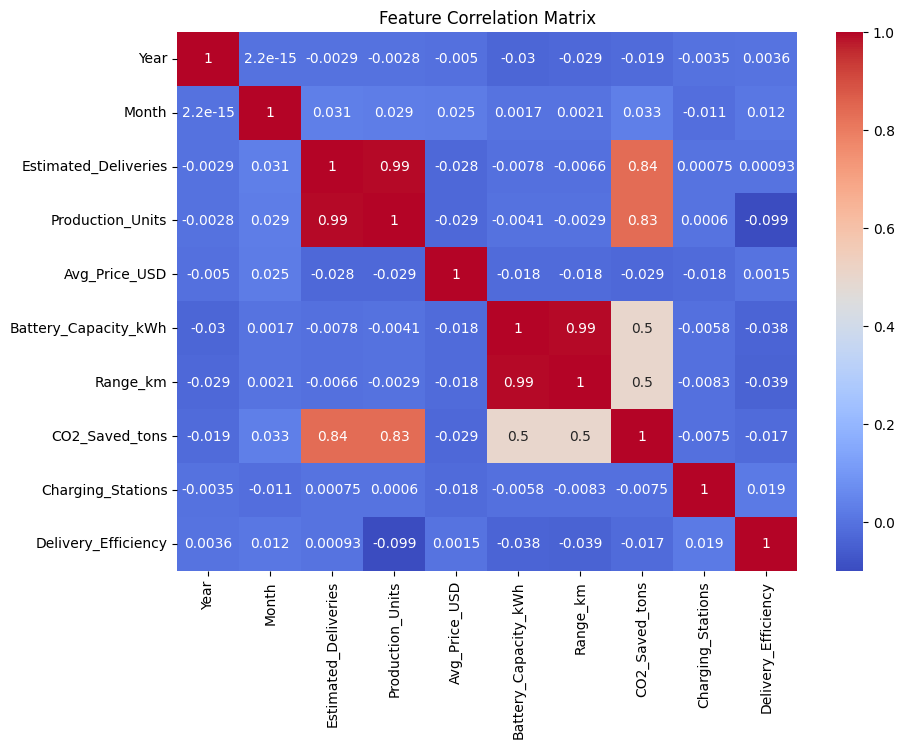

In [ ]:
numeric_cols = tesla_df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
# Machine Learning Model

# Random Forest Regression is used to predict estimated deliveries using production, pricing, battery, and regional information.

In [ ]:
target = tesla_df["Estimated_Deliveries"]

features = tesla_df.drop(
    columns=["Estimated_Deliveries", "Date"]
)

features = pd.get_dummies(
    features,
    drop_first=True
)

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42
)

In [ ]:
delivery_model = RandomForestRegressor(
    random_state=42
)

delivery_model.fit(X_train, y_train)

predicted_values = delivery_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, predicted_values)

rmse = np.sqrt(
    mean_squared_error(y_test, predicted_values)
)

r2 = r2_score(y_test, predicted_values)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 65.70
RMSE : 108.87
R²   : 0.9992


In [ ]:
parameter_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=parameter_grid,
    cv=3,
    scoring="r2"
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
monthly_deliveries = (
    tesla_df.groupby("Date")["Estimated_Deliveries"]
    .sum()
)

monthly_deliveries = monthly_deliveries.asfreq('MS')

In [ ]:
forecast_model = ARIMA(
    monthly_deliveries,
    order=(5,1,0)
)

forecast_results = forecast_model.fit()

future_forecast = forecast_results.forecast(
    steps=12
)

print(future_forecast)

2026-01-01    203819.655291
2026-02-01    202894.176208
2026-03-01    199011.662577
2026-04-01    198667.010489
2026-05-01    200971.493839
2026-06-01    201391.449843
2026-07-01    201412.663910
2026-08-01    201031.409119
2026-09-01    200601.086701
2026-10-01    200710.068214
2026-11-01    200864.721560
2026-12-01    200936.680134
Freq: MS, Name: predicted_mean, dtype: float64


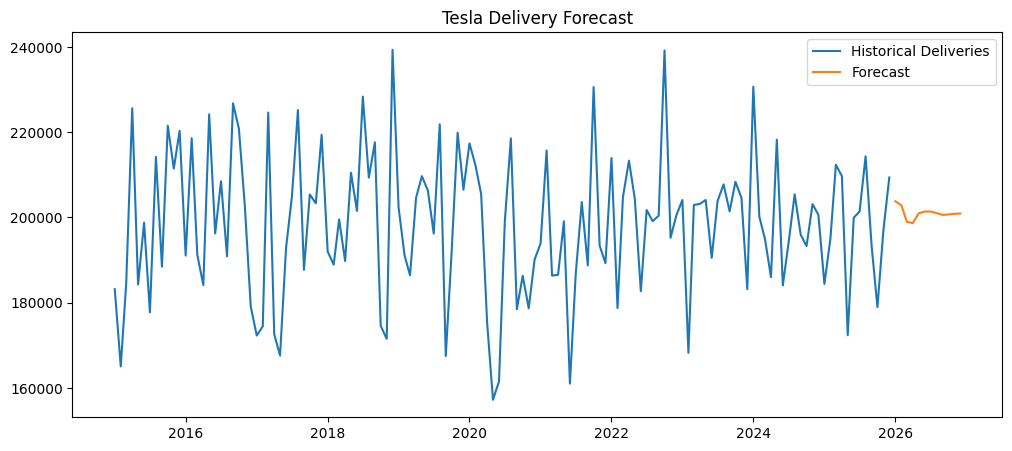

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_deliveries,
    label="Historical Deliveries"
)

plt.plot(
    future_forecast.index,
    future_forecast.values,
    label="Forecast"
)

plt.title("Tesla Delivery Forecast")
plt.legend()
plt.show()

In [ ]:
# Conclusion

# The project successfully analyzed Tesla EV performance data and built a predictive pipeline for delivery forecasting. Feature engineering and regression modeling helped identify important business drivers, while ARIMA forecasting was used to estimate future delivery trends.

In [ ]:
## Model Performance

# The Random Forest Regressor achieved strong predictive performance:

# - Mean Absolute Error (MAE): 65.70
# - Root Mean Squared Error (RMSE): 108.87
# - R² Score: 0.9992

# The high R² score indicates that the model explains almost all variability in delivery estimates, while the low error values suggest accurate predictions.